<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/Kalyani_bland_Altman_plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np


In [5]:
df=pd.read_excel('/content/drive/MyDrive/Dr Kalyani thesis training Dataset KH KV AL ACD LT.xlsx')


In [7]:
X = df[['KH','KV','AGE ']]
y = df['AL']

In [16]:
# prompt: Linear regression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Print the coefficients and intercept
print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)

# Evaluate the model (optional)
from sklearn.metrics import mean_squared_error, r2_score

print('Mean squared error: %.2f' % mean_squared_error(y_test, y_pred))
print('Coefficient of determination (R^2): %.2f' % r2_score(y_test, y_pred))

# Plot results (optional, only works well for single feature)
if X.shape[1] == 1:
  plt.scatter(X_test, y_test, color='black')
  plt.plot(X_test, y_pred, color='blue', linewidth=3)
  plt.xlabel(X.columns[0])
  plt.ylabel(y.name)
  plt.title('Linear Regression')
  plt.show()

Coefficients: [-0.18133518 -0.16295744  0.015093  ]
Intercept: 37.29650771156582
Mean squared error: 0.44
Coefficient of determination (R^2): 0.65


In [20]:
# prompt: Create predicted values column

import numpy as np
# Add the predicted values to the original dataframe or a new dataframe
# We will add it to the original dataframe based on the test set indices

# Create a copy of the test set part of the original dataframe
df_test = df.loc[X_test.index].copy()

# Add the predicted values as a new column to the test set dataframe
df_test['AL_predicted'] = y_pred

# Now, if you want to see the predicted values alongside the actual values and features for the test set:
print(df_test[['KH', 'KV', 'AGE ', 'AL', 'AL_predicted']])

# If you want to merge these predicted values back into the original dataframe
# First, create a new column initialized with NaN
#df['AL_predicted'] = np.nan

# Update the 'AL_predicted' column for the rows corresponding to the test set indices
df.loc[X_test.index, 'AL_predicted'] = y_pred

# Now the original 'df' dataframe has a new column 'AL_predicted'
# The values for the training data rows in this column will be NaN
print("\nOriginal DataFrame with predicted values for the test set:")
print(df[['KH', 'KV', 'AGE ', 'AL', 'AL_predicted']].head())
print(df[['KH', 'KV', 'AGE ', 'AL', 'AL_predicted']].tail())

        KH     KV  AGE      AL  AL_predicted
268  43.50  44.00    59  23.50     23.128787
73   47.75  48.25    61  21.11     21.695730
289  46.00  46.75    51  21.80     22.106572
155  48.50  48.50    55  21.59     21.428431
104  44.50  45.75    50  22.40     22.526440
..     ...    ...   ...    ...           ...
86   42.75  43.75    64  23.81     23.380993
75   46.50  47.50    65  21.61     22.104989
441  45.25  46.00    64  21.70     22.561001
15   44.75  44.25    57  22.80     22.831193
250  45.25  44.25    60  23.55     22.785804

[101 rows x 5 columns]

Original DataFrame with predicted values for the test set:
      KH     KV  AGE      AL  AL_predicted
0  45.75  43.25    65  21.90     22.933559
1  44.25  44.75    65  22.97           NaN
2  42.25  43.00    79  23.76     23.820274
3  43.25  43.75    69  22.77           NaN
4  44.00  46.75    72  22.99           NaN
        KH     KV  AGE     AL  AL_predicted
498  46.00  46.75    59  21.3     22.227316
499  41.00  41.50    74  24.8 

In [21]:
df_test

,AGE,SEX,KH,KV,AXIS,AL,ACD,LT,AL_predicted
268,59,M,43.50,44.00,130.0,23.50,3.50,3.70,23.128787
73,61,M,47.75,48.25,135.0,21.11,3.33,4.25,21.695730
289,51,F,46.00,46.75,170.0,21.80,2.85,4.40,22.106572
155,55,M,48.50,48.50,90.0,21.59,2.68,2.35,21.428431
104,50,M,44.50,45.75,70.0,22.40,3.56,3.25,22.526440
...,...,...,...,...,...,...,...,...,...
86,64,M,42.75,43.75,45.0,23.81,2.45,3.66,23.380993
75,65,F,46.50,47.50,40.0,21.61,3.65,4.25,22.104989
441,64,M,45.25,46.00,80.0,21.70,2.95,4.20,22.561001
15,57,F,44.75,44.25,45.0,22.80,3.64,4.00,22.831193


In [23]:
# prompt: Correlate df and df_test

# Select the columns you want to correlate
# For example, correlating 'AL' and 'AL_predicted' from df_test
correlation = df_test[['AL', 'AL_predicted']].corr()

print("\nCorrelation between AL and AL_predicted in the test set:")
print(correlation)

# You can also correlate the entire df_test dataframe
# This will show the correlation matrix for all columns in df_test
print("\nCorrelation matrix for the df_test dataframe:")
#print(df_test.corr())

# If you want to correlate df and df_test based on common columns and indices
# This requires merging or aligning the dataframes first
# Since df_test is already a subset of df based on test indices,
# correlating corresponding columns directly from df and df_test is not the standard approach for model evaluation.
# You would typically correlate the actual values from the test set (y_test) with the predicted values (y_pred),
# which is what the R-squared score and the correlation calculated above for df_test[['AL', 'AL_predicted']] represent.

# If the task implies correlating the original features with the predicted values,
# you would do that within the test set dataframe (df_test).
# For example, correlating 'KH' with 'AL_predicted' in the test set:
print("\nCorrelation between KH and AL_predicted in the test set:")
print(df_test[['KH', 'AL_predicted']].corr())


Correlation between AL and AL_predicted in the test set:
                    AL  AL_predicted
AL            1.000000      0.821997
AL_predicted  0.821997      1.000000

Correlation matrix for the df_test dataframe:

Correlation between KH and AL_predicted in the test set:
                    KH  AL_predicted
KH            1.000000     -0.974664
AL_predicted -0.974664      1.000000


In [24]:
# prompt: T test

from scipy import stats

# Perform a paired t-test on the actual vs predicted values in the test set
# This tests if the mean difference between actual and predicted values is significantly different from zero.
t_statistic, p_value = stats.ttest_rel(df_test['AL'], df_test['AL_predicted'])

print("\nPaired t-test between actual AL and predicted AL in the test set:")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation:
# A low p-value (typically < 0.05) suggests that there is a statistically significant difference
# between the means of the two paired samples (actual vs. predicted).
# A high p-value suggests that the difference is not statistically significant.
# In the context of model evaluation, a non-significant p-value might be desired,
# indicating that the predicted values are not statistically different from the actual values on average.
# However, a paired t-test primarily tests for mean differences, not the overall accuracy or fit.


Paired t-test between actual AL and predicted AL in the test set:
T-statistic: 1.0191
P-value: 0.3106


Dataset loaded successfully.
   AGE  SEX     KH     KV  AXIS     AL   ACD    LT
0    65   M  45.75  43.25  15.0  21.90  2.35  3.45
1    65   M  44.25  44.75  25.0  22.97  3.56  3.45
2    79   M  42.25  43.00  30.0  23.76  2.44  4.56
3    69   M  43.25  43.75  90.0  22.77  2.98  3.78
4    72   M  44.00  46.75  95.0  22.99  3.45  3.78

Features (X) and target (y) defined.
X shape: (503, 3)
y shape: (503,)

Data split into training (80%) and testing (20%) sets.
X_train shape: (402, 3)
X_test shape: (101, 3)
y_train shape: (402,)
y_test shape: (101,)

Linear Regression model trained.

Predictions made on the test set.

Model Coefficients:
Coefficients: [-0.18133518 -0.16295744  0.015093  ]
Intercept: 37.29650771156582

Model Evaluation Metrics:
Mean Squared Error (MSE): 0.4449
Coefficient of Determination (R^2): 0.6472

Test Set Results (Actual vs. Predicted):
     AL_Actual  AL_Predicted
268      23.50     23.128787
73       21.11     21.695730
289      21.80     22.106572
155      21.59 

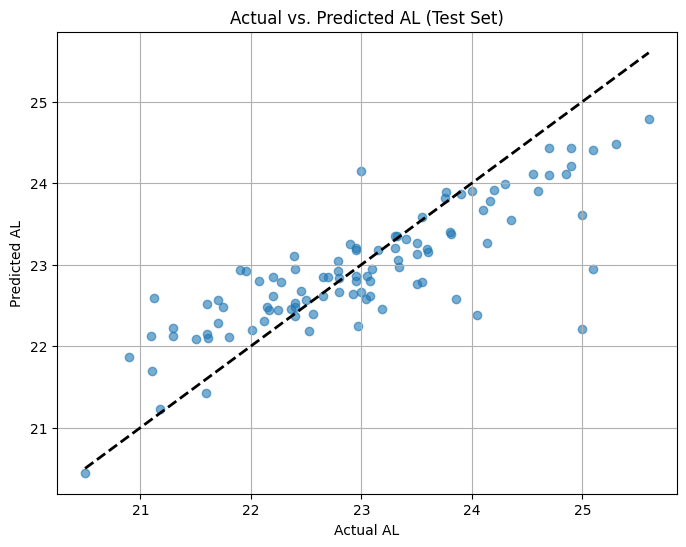

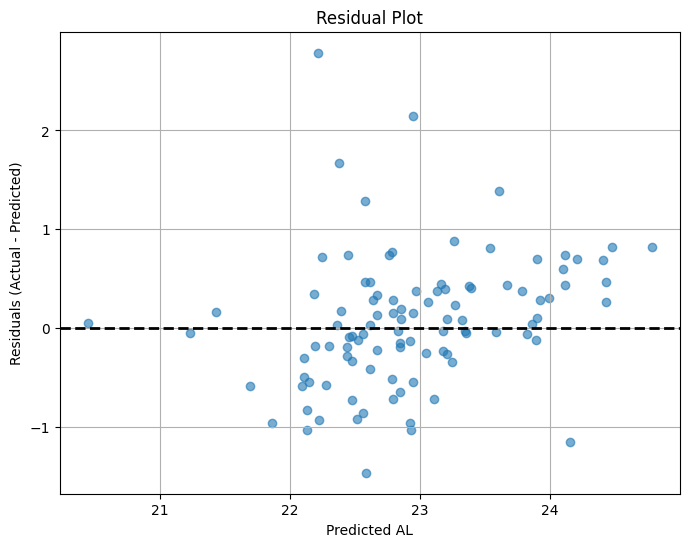


Paired t-test between Actual AL and Predicted AL in the test set:
T-statistic: 1.0191
P-value: 0.3106

Correlation of Features with Predicted AL in the test set:
KH             -0.974664
KV             -0.954134
AGE             0.677400
AL_Predicted    1.000000
Name: AL_Predicted, dtype: float64


In [26]:
# prompt: Linear regression

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats
from google.colab import drive

# Mount Google Drive
#drive.mount('/content/drive')

# Load the dataset
# Ensure the file path is correct
try:
    df = pd.read_excel('/content/drive/MyDrive/Dr Kalyani thesis training Dataset KH KV AL ACD LT.xlsx')
    print("Dataset loaded successfully.")
    print(df.head())
except FileNotFoundError:
    print("Error: Dataset file not found. Please check the file path.")
    # Exit or handle the error appropriately if the file is not found
    exit()

# Define features (X) and target (y)
# Ensure the column names match exactly what's in your Excel file
# If column names have leading/trailing spaces, you might need to strip them
# print(df.columns) # Uncomment to see the exact column names
try:
    X = df[['KH', 'KV', 'AGE ']]
    y = df['AL']
    print("\nFeatures (X) and target (y) defined.")
    print("X shape:", X.shape)
    print("y shape:", y.shape)
except KeyError as e:
    print(f"Error: Column not found in the DataFrame. Please check the column name: {e}")
    exit()


# Split data into training and testing sets
# random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nData split into training (80%) and testing (20%) sets.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("\nLinear Regression model trained.")

# Make predictions on the test set
y_pred = model.predict(X_test)

print("\nPredictions made on the test set.")

# Print the coefficients and intercept
print('\nModel Coefficients:')
print('Coefficients:', model.coef_) # These are the slopes for each feature in X
print('Intercept:', model.intercept_) # This is the y-intercept

# Evaluate the model using common regression metrics
print('\nModel Evaluation Metrics:')
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error (MSE): {mse:.4f}') # Lower values indicate better fit
print(f'Coefficient of Determination (R^2): {r2:.4f}') # 1 indicates perfect fit, 0 means no linear relationship

# --- Analysis of Predictions ---

# Add the predicted values to a dataframe for easier comparison and analysis
# Create a new dataframe containing the actual test set data and the predictions
df_results = X_test.copy() # Start with the features from the test set
df_results['AL_Actual'] = y_test # Add the actual target values
df_results['AL_Predicted'] = y_pred # Add the predicted target values

print("\nTest Set Results (Actual vs. Predicted):")
print(df_results[['AL_Actual', 'AL_Predicted']].head()) # Display first few rows
print(df_results[['AL_Actual', 'AL_Predicted']].tail()) # Display last few rows

# Calculate Correlation between Actual and Predicted values
correlation_actual_predicted = df_results['AL_Actual'].corr(df_results['AL_Predicted'])
print(f"\nCorrelation between Actual AL and Predicted AL in the test set: {correlation_actual_predicted:.4f}")

# Plot Actual vs. Predicted values
plt.figure(figsize=(8, 6))
plt.scatter(df_results['AL_Actual'], df_results['AL_Predicted'], alpha=0.6) # Scatter plot of actual vs predicted
plt.plot([df_results['AL_Actual'].min(), df_results['AL_Actual'].max()],
         [df_results['AL_Actual'].min(), df_results['AL_Actual'].max()],
         'k--', lw=2) # Plot a diagonal line (y=x) for perfect predictions
plt.xlabel('Actual AL')
plt.ylabel('Predicted AL')
plt.title('Actual vs. Predicted AL (Test Set)')
plt.grid(True)
plt.show()


# Plot Residuals (Actual - Predicted)
# Residuals should ideally be randomly scattered around 0 with no obvious pattern
residuals = df_results['AL_Actual'] - df_results['AL_Predicted']
plt.figure(figsize=(8, 6))
plt.scatter(df_results['AL_Predicted'], residuals, alpha=0.6)
plt.axhline(y=0, color='k', linestyle='--', lw=2) # Horizontal line at 0
plt.xlabel('Predicted AL')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

# Perform a Paired t-test on the actual vs predicted values in the test set
# This tests if the mean difference between actual and predicted values is significantly different from zero.
# Use the .values to ensure they are treated as numpy arrays by ttest_rel
t_statistic, p_value = stats.ttest_rel(df_results['AL_Actual'], df_results['AL_Predicted'])

print("\nPaired t-test between Actual AL and Predicted AL in the test set:")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation:
# A low p-value (typically < 0.05) suggests that there is a statistically significant difference
# between the means of the two paired samples (actual vs. predicted).
# A high p-value suggests that the difference is not statistically significant.
# In the context of model evaluation, a non-significant p-value might be desired,
# indicating that the predicted values are not statistically different from the actual values on average.
# However, a paired t-test primarily tests for mean differences, not the overall accuracy or fit.

# --- Optional: Correlate features with predicted values ---
# You can see how strongly individual input features correlate with the predictions
print("\nCorrelation of Features with Predicted AL in the test set:")
print(df_results[['KH', 'KV', 'AGE ', 'AL_Predicted']].corr()['AL_Predicted'])



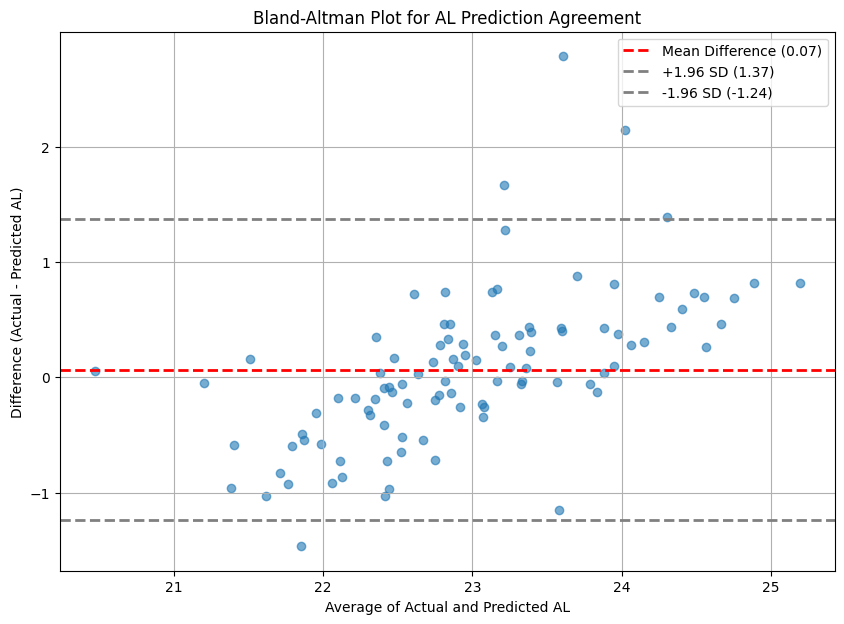


Bland-Altman Analysis Summary:
Mean Difference (Bias): 0.0676
Standard Deviation of Differences: 0.6669
95% Limits of Agreement: (-1.2394, 1.3746)


In [30]:
# prompt: Bland-Altman

import matplotlib.pyplot as plt
# --- Bland-Altman Plot ---
# The Bland-Altman plot is a graphical method to evaluate the agreement between two quantitative measurements.
# In this case, we'll use it to assess the agreement between the actual AL values and the predicted AL values
# from our linear regression model on the test set.

# Calculate the difference between the two measurements (Actual - Predicted)
difference = df_results['AL_Actual'] - df_results['AL_Predicted']

# Calculate the average of the two measurements
average = (df_results['AL_Actual'] + df_results['AL_Predicted']) / 2

# Calculate the mean of the differences (Bias)
mean_difference = difference.mean()

# Calculate the standard deviation of the differences
std_difference = difference.std()

# Calculate the Limits of Agreement (LoA): Mean Difference ± 1.96 * Standard Deviation
# 1.96 is the Z-score for the 95% confidence interval under the assumption of normality
lower_loa = mean_difference - 1.96 * std_difference
upper_loa = mean_difference + 1.96 * std_difference

# Create the Bland-Altman plot
plt.figure(figsize=(10, 7))

# Scatter plot of the differences against the averages
plt.scatter(average, difference, alpha=0.6)

# Plot the Mean Difference line (Bias)
plt.axhline(mean_difference, color='red', linestyle='--', lw=2, label=f'Mean Difference ({mean_difference:.2f})')

# Plot the Limits of Agreement lines
plt.axhline(upper_loa, color='gray', linestyle='--', lw=2, label=f'+1.96 SD ({upper_loa:.2f})')
plt.axhline(lower_loa, color='gray', linestyle='--', lw=2, label=f'-1.96 SD ({lower_loa:.2f})')

plt.xlabel('Average of Actual and Predicted AL')
plt.ylabel('Difference (Actual - Predicted AL)')
plt.title('Bland-Altman Plot for AL Prediction Agreement')
plt.legend()
plt.grid(True)
plt.show()

# Interpretation of the Bland-Altman Plot:
# - The plot shows the difference between the two measurements against their average.
# - The red dashed line represents the mean difference (bias). If the bias is close to zero, there is little systematic difference between the measurements.
# - The gray dashed lines represent the 95% Limits of Agreement (LoA). Approximately 95% of the differences between the two measurements should lie within these limits, assuming the differences are normally distributed and there is no systematic trend.
# - Points outside the LoA might indicate poor agreement for those specific data points.
# - A trend in the plot (e.g., differences increasing or decreasing as the average increases) indicates that the agreement depends on the magnitude of the measurement. This suggests proportional bias.
# - For clinical or practical use, one would assess if the LoA are clinically acceptable. Wide limits suggest poor agreement.

print("\nBland-Altman Analysis Summary:")
print(f"Mean Difference (Bias): {mean_difference:.4f}")
print(f"Standard Deviation of Differences: {std_difference:.4f}")
print(f"95% Limits of Agreement: ({lower_loa:.4f}, {upper_loa:.4f})")


In [29]:
df_results

,KH,KV,AGE,AL_Actual,AL_Predicted
268,43.50,44.00,59,23.50,23.128787
73,47.75,48.25,61,21.11,21.695730
289,46.00,46.75,51,21.80,22.106572
155,48.50,48.50,55,21.59,21.428431
104,44.50,45.75,50,22.40,22.526440
...,...,...,...,...,...
86,42.75,43.75,64,23.81,23.380993
75,46.50,47.50,65,21.61,22.104989
441,45.25,46.00,64,21.70,22.561001
15,44.75,44.25,57,22.80,22.831193



Shapiro-Wilk Test for Normality of Residuals:
Test Statistic: 0.9514
P-value: 0.0010


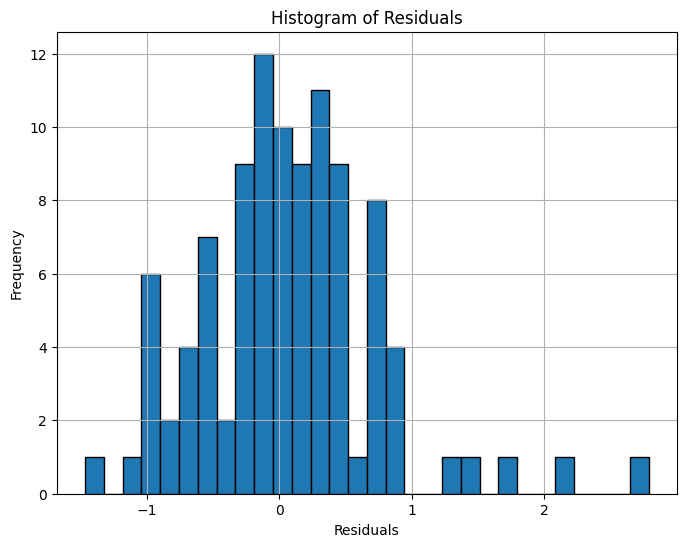

In [31]:
# prompt: Any other

import matplotlib.pyplot as plt
# --- Shapiro-Wilk Test for Normality of Residuals ---
# The Shapiro-Wilk test is used to test if the residuals are normally distributed.
# Normality of residuals is an assumption for classical linear regression and is important for the validity of some statistical tests and confidence intervals.

# Perform the Shapiro-Wilk test on the residuals
shapiro_test_statistic, shapiro_p_value = stats.shapiro(residuals)

print("\nShapiro-Wilk Test for Normality of Residuals:")
print(f"Test Statistic: {shapiro_test_statistic:.4f}")
print(f"P-value: {shapiro_p_value:.4f}")

# Interpretation:
# - The null hypothesis (H0) is that the data are drawn from a normal distribution.
# - The alternative hypothesis (H1) is that the data are not drawn from a normal distribution.
# - If the p-value is less than the chosen significance level (e.g., 0.05), we reject the null hypothesis and conclude that the residuals are likely not normally distributed.
# - If the p-value is greater than the significance level, we fail to reject the null hypothesis, suggesting that the residuals are consistent with a normal distribution.

# Note: The Shapiro-Wilk test is sensitive, especially with larger sample sizes.
# Non-normality of residuals doesn't necessarily invalidate the entire linear regression model,
# but it can affect the accuracy of p-values and confidence intervals.
# Visual inspection of the residual plot and a histogram of residuals can also be helpful.

# Plot a histogram of the residuals to visually assess normality
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.grid(True)
plt.show()



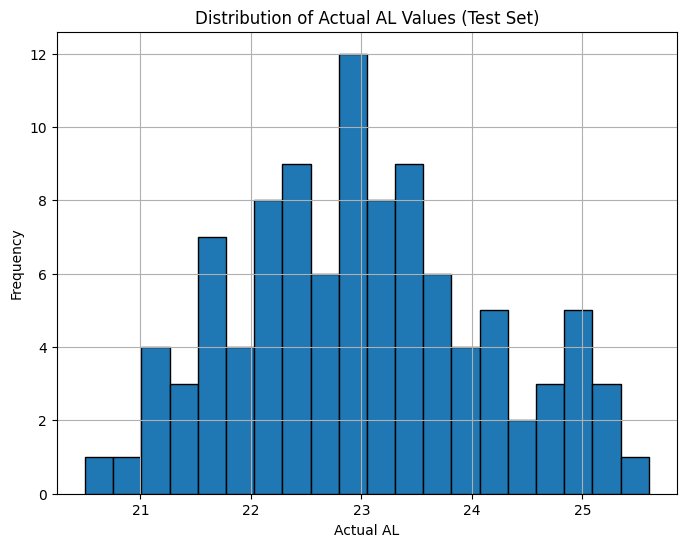

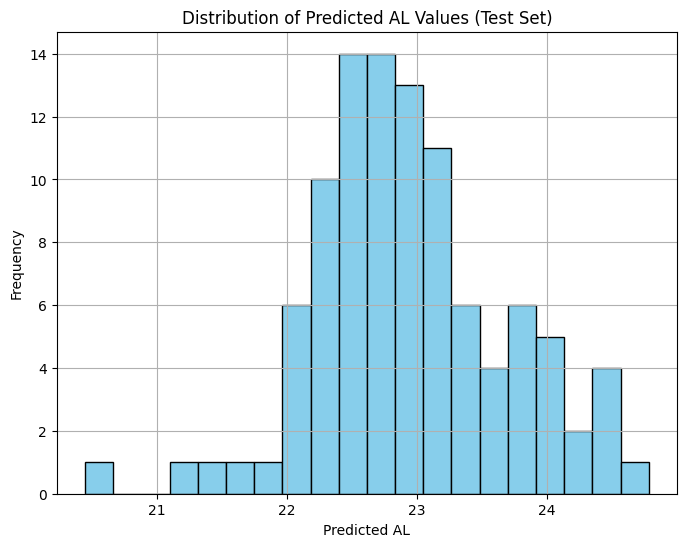

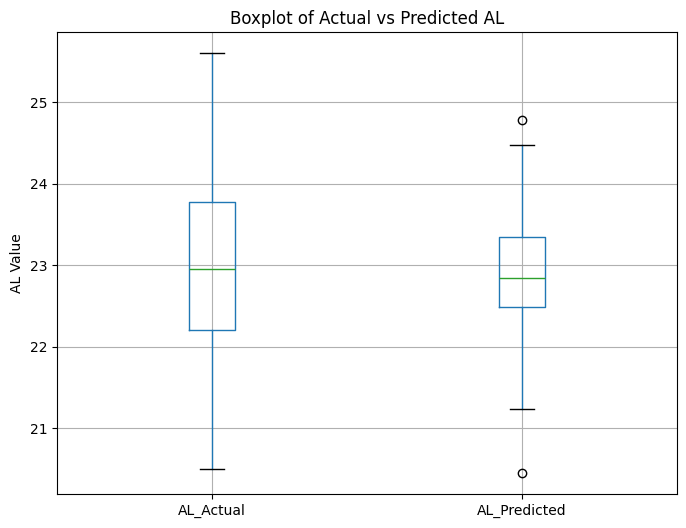


Generating Pairplot of Features and Actual/Predicted AL...


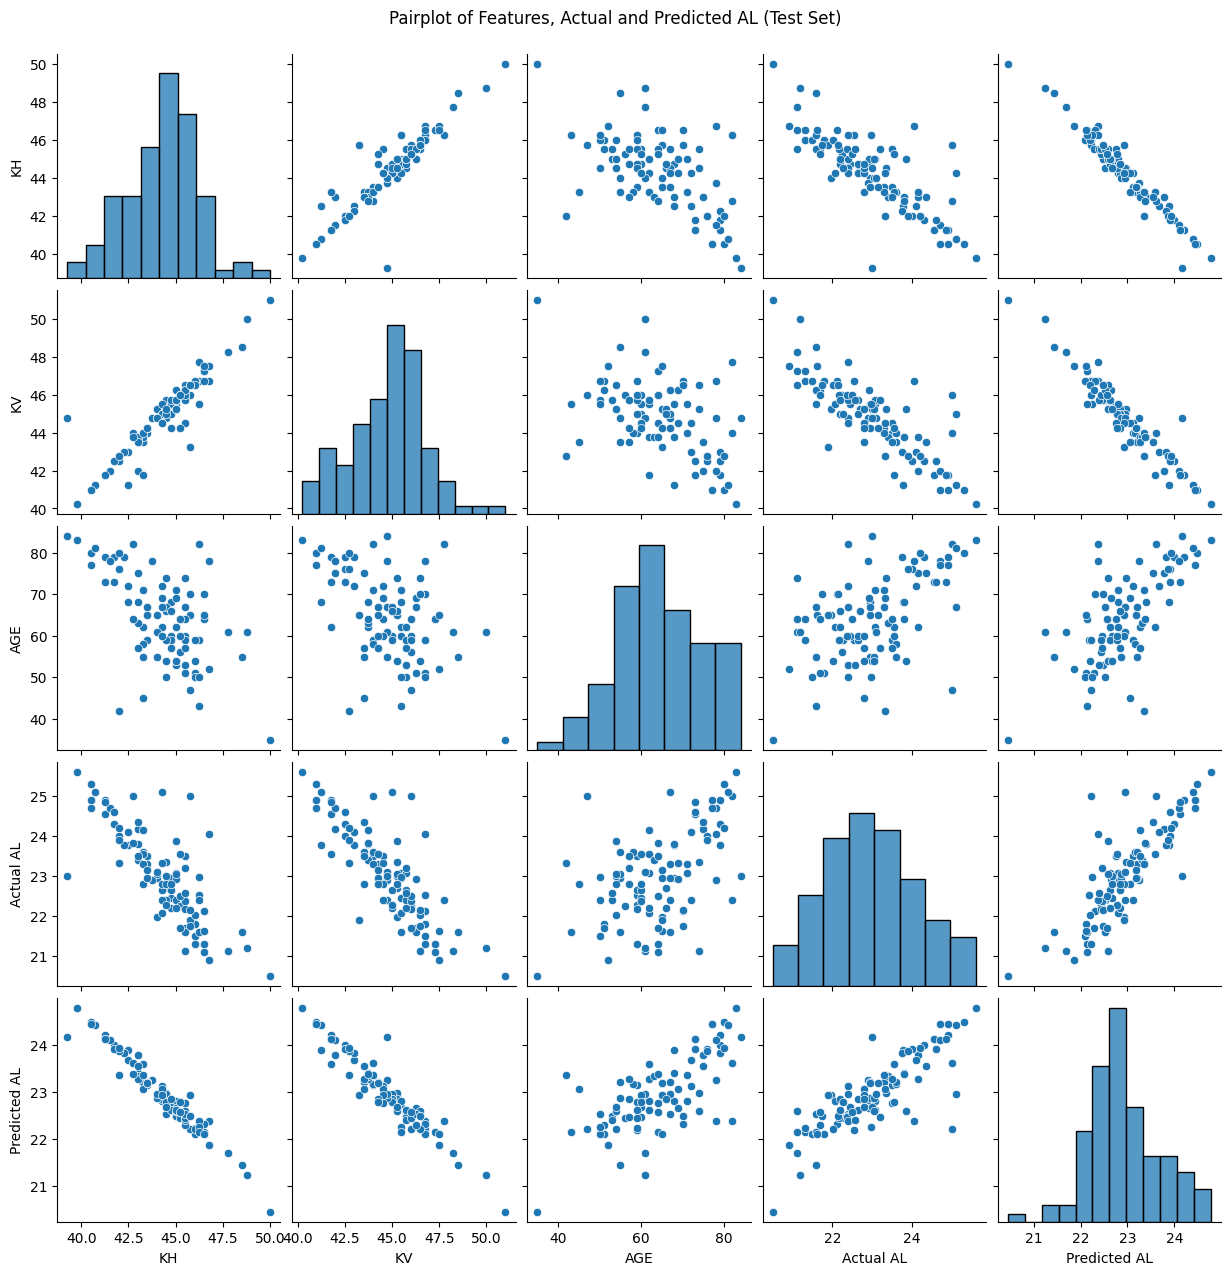

Pairplot generated.

Root Mean Squared Error (RMSE): 0.6670
Mean Absolute Error (MAE): 0.4890
                            OLS Regression Results                            
Dep. Variable:                     AL   R-squared:                       0.465
Model:                            OLS   Adj. R-squared:                  0.461
Method:                 Least Squares   F-statistic:                     115.3
Date:                Mon, 07 Jul 2025   Prob (F-statistic):           9.67e-54
Time:                        01:40:19   Log-Likelihood:                -443.43
No. Observations:                 402   AIC:                             894.9
Df Residuals:                     398   BIC:                             910.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

In [32]:
# prompt: Any other

import matplotlib.pyplot as plt
import numpy as np
# --- Additional Plots and Analysis ---

# Plot the distribution of the actual AL values
plt.figure(figsize=(8, 6))
df_results['AL_Actual'].hist(bins=20, edgecolor='black')
plt.xlabel('Actual AL')
plt.ylabel('Frequency')
plt.title('Distribution of Actual AL Values (Test Set)')
plt.grid(True)
plt.show()

# Plot the distribution of the predicted AL values
plt.figure(figsize=(8, 6))
df_results['AL_Predicted'].hist(bins=20, edgecolor='black', color='skyblue')
plt.xlabel('Predicted AL')
plt.ylabel('Frequency')
plt.title('Distribution of Predicted AL Values (Test Set)')
plt.grid(True)
plt.show()

# Boxplot of actual vs predicted AL
plt.figure(figsize=(8, 6))
df_results[['AL_Actual', 'AL_Predicted']].boxplot()
plt.ylabel('AL Value')
plt.title('Boxplot of Actual vs Predicted AL')
plt.grid(True)
plt.show()

# Pairplot of features and actual/predicted AL in the test set
# This can help visualize relationships between features and the target/prediction
import seaborn as sns

# Combine features, actual, and predicted values for pairplot
df_pairplot = df_results[['KH', 'KV', 'AGE ', 'AL_Actual', 'AL_Predicted']]

# Relabel columns for clearer plot titles
df_pairplot = df_pairplot.rename(columns={
    'AL_Actual': 'Actual AL',
    'AL_Predicted': 'Predicted AL',
    'KH': 'KH',
    'KV': 'KV',
    'AGE ': 'AGE' # Assuming 'AGE ' should be 'AGE'
})


# Note: Pairplot can be computationally intensive for large datasets or many features
# It generates a grid of scatterplots for each pair of variables, and histograms/KDE plots on the diagonal.
try:
    print("\nGenerating Pairplot of Features and Actual/Predicted AL...")
    sns.pairplot(df_pairplot)
    plt.suptitle('Pairplot of Features, Actual and Predicted AL (Test Set)', y=1.02) # Adjust title position
    plt.show()
    print("Pairplot generated.")
except Exception as e:
    print(f"Error generating Pairplot: {e}")


# Calculate and print Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f'\nRoot Mean Squared Error (RMSE): {rmse:.4f}') # RMSE is in the same units as the target variable

# Calculate Mean Absolute Error (MAE)
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error (MAE): {mae:.4f}') # MAE is also in the same units as the target variable, less sensitive to outliers than MSE/RMSE


# Confidence intervals for coefficients (requires statsmodels)
!pip install statsmodels
import statsmodels.api as sm

# Add a constant to the features for the intercept
X_train_sm = sm.add_constant(X_train)

# Create and fit OLS model from statsmodels
# This provides more detailed statistical output, including coefficient confidence intervals
try:
    model_sm = sm.OLS(y_train, X_train_sm).fit()
    print(model_sm.summary())
except Exception as e:
    print(f"\nCould not generate statsmodels summary: {e}")
    print("Ensure all columns in X_train are numeric and have no infinite values.")



<Figure size 800x600 with 0 Axes>

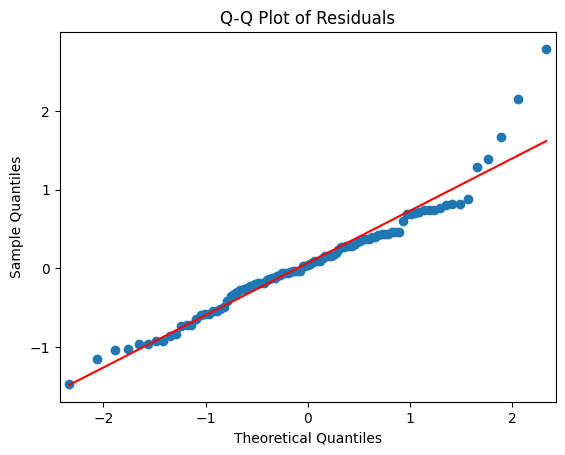


Q-Q plot generated to assess normality of residuals.


In [33]:
# prompt: Any other

import matplotlib.pyplot as plt
# Q-Q plot of Residuals
# This helps to check the assumption of normality of residuals.
# If residuals are normally distributed, the points should fall approximately along the diagonal line.
plt.figure(figsize=(8, 6))
sm.qqplot(residuals, line='s') # 's' for standardized line
plt.title('Q-Q Plot of Residuals')
plt.show()

print("\nQ-Q plot generated to assess normality of residuals.")


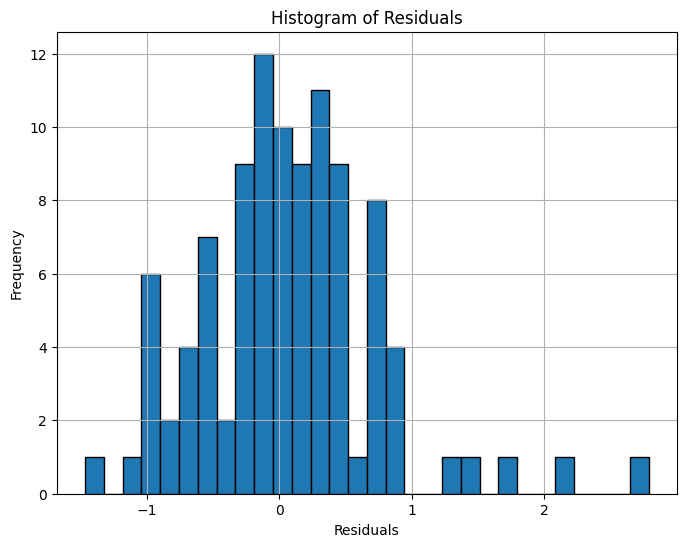

In [34]:
# prompt: Histogram

import matplotlib.pyplot as plt
# Plot a histogram of the residuals to visually assess normality
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.grid(True)
plt.show()

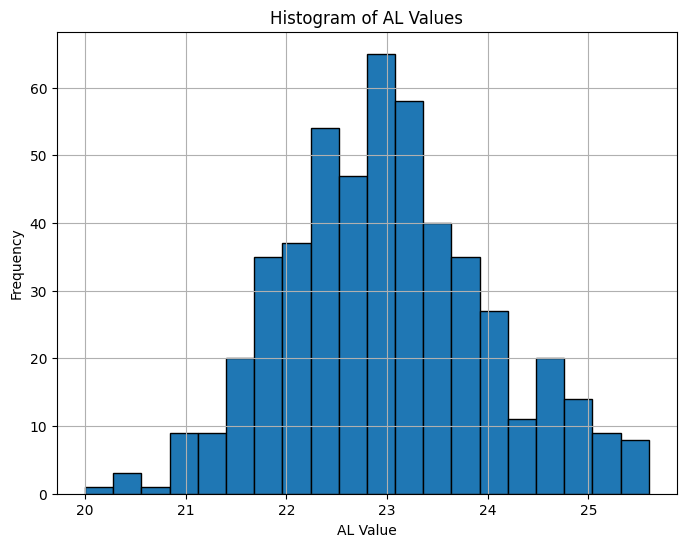

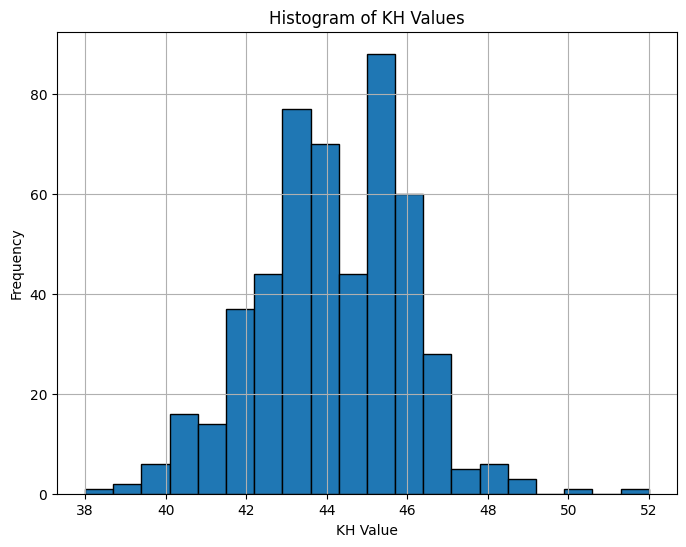

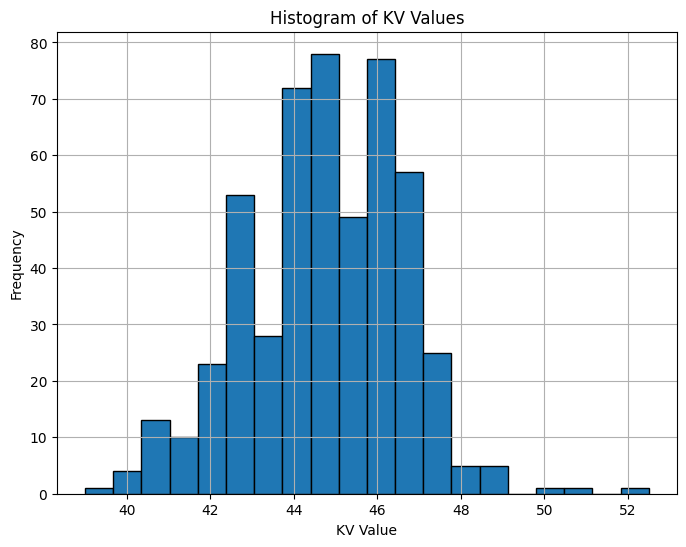

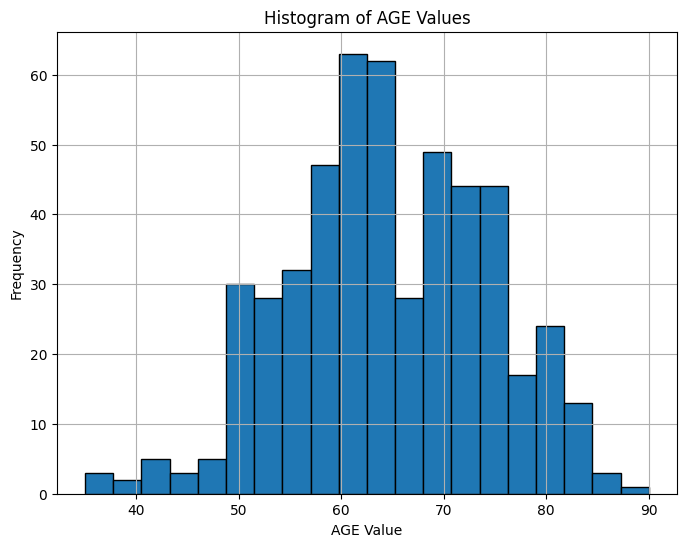

In [35]:
# prompt: Histogram

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
df['AL'].hist(bins=20, edgecolor='black')
plt.xlabel('AL Value')
plt.ylabel('Frequency')
plt.title('Histogram of AL Values')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
df['KH'].hist(bins=20, edgecolor='black')
plt.xlabel('KH Value')
plt.ylabel('Frequency')
plt.title('Histogram of KH Values')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
df['KV'].hist(bins=20, edgecolor='black')
plt.xlabel('KV Value')
plt.ylabel('Frequency')
plt.title('Histogram of KV Values')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
df['AGE '].hist(bins=20, edgecolor='black')
plt.xlabel('AGE Value')
plt.ylabel('Frequency')
plt.title('Histogram of AGE Values')
plt.grid(True)
plt.show()

In [36]:
# prompt: Any other

import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each feature in the training set
# Add a constant to the features for the intercept term in VIF calculation
X_vif = sm.add_constant(X_train)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

print("\nVariance Inflation Factors (VIF):")
vif_data

# Interpretation of VIF:
# - VIF = 1: No correlation between this feature and others.
# - 1 < VIF < 5: Moderate correlation.
# - VIF >= 5 or 10: High correlation (multicollinearity) - potentially problematic.
# High VIF values suggest that the coefficient estimates might be unreliable or unstable.
# If multicollinearity is high, consider removing one of the correlated features or using techniques like PCA.




Variance Inflation Factors (VIF):


,feature,VIF
0,const,832.445576
1,KH,7.210090
2,KV,7.182203
3,AGE,1.102394


In [37]:
# prompt: Any other

import matplotlib.pyplot as plt
import numpy as np
# Check the data types of the features and target
print("\nData types of features and target:")
print(X_train.dtypes)
print(y_train.dtypes)

# Check for missing values in the training set
print("\nMissing values in training set:")
print(X_train.isnull().sum())
print(y_train.isnull().sum())

# Check for infinite values in the training set
print("\nInfinite values in training set:")
print(np.isinf(X_train).sum())
print(np.isinf(y_train).sum())


# --- Cross-Validation (Optional but Recommended) ---
# Cross-validation provides a more robust estimate of model performance
# by evaluating it on multiple train-test splits of the data.

from sklearn.model_selection import cross_val_score

print("\nPerforming 5-fold Cross-Validation:")

# Evaluate the model using cross-validation
# Scoring can be 'neg_mean_squared_error', 'r2', 'neg_mean_absolute_error', etc.
# Note: cross_val_score returns negative MSE/MAE because scikit-learn scoring functions
# follow the convention that higher values are better.
cv_scores_mse = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_r2 = cross_val_score(model, X, y, cv=5, scoring='r2')
cv_scores_mae = cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')

# Convert negative scores to positive
cv_scores_rmse = np.sqrt(-cv_scores_mse)
cv_scores_mae_pos = -cv_scores_mae

print(f"\nCross-validation Mean Squared Errors (5 folds): {cv_scores_mse}")
print(f"Average CV MSE: {np.mean(cv_scores_mse):.4f}")
print(f"Standard Deviation of CV MSE: {np.std(cv_scores_mse):.4f}")

print(f"\nCross-validation R^2 Scores (5 folds): {cv_scores_r2}")
print(f"Average CV R^2: {np.mean(cv_scores_r2):.4f}")
print(f"Standard Deviation of CV R^2: {np.std(cv_scores_r2):.4f}")

print(f"\nCross-validation Root Mean Squared Errors (5 folds): {cv_scores_rmse}")
print(f"Average CV RMSE: {np.mean(cv_scores_rmse):.4f}")
print(f"Standard Deviation of CV RMSE: {np.std(cv_scores_rmse):.4f}")


print(f"\nCross-validation Mean Absolute Errors (5 folds): {cv_scores_mae_pos}")
print(f"Average CV MAE: {np.mean(cv_scores_mae_pos):.4f}")
print(f"Standard Deviation of CV MAE: {np.std(cv_scores_mae_pos):.4f}")


# Interpretation of Cross-Validation Results:
# - The average scores give a more reliable estimate of how the model will perform on unseen data.
# - The standard deviation of the scores indicates the variability of the model's performance across different data splits.
#   A high standard deviation might suggest that the model's performance is sensitive to the specific data used for training.

# --- Further Model Diagnostics (using statsmodels) ---
# statsmodels provides more detailed statistical diagnostics for regression models.

# Ensure statsmodels is installed
!pip install statsmodels

# Add a constant to the features for the intercept
X_sm = sm.add_constant(X) # Use the full dataset features for this analysis

# Create and fit OLS model using the full dataset
# This model is for statistical inference on the entire dataset,
# not for performance evaluation on the test set (which we already did).
try:
    model_full_sm = sm.OLS(y, X_sm).fit()
    print("\nStatsmodels OLS Regression Results (Full Dataset):")
    print(model_full_sm.summary())
except Exception as e:
    print(f"\nCould not generate statsmodels summary for full dataset: {e}")
    print("Ensure all columns in X are numeric and have no infinite values.")

# Interpretation of statsmodels summary:
# - R-squared and Adjusted R-squared: Similar to the scikit-learn R^2, indicating the proportion of variance in the target explained by the features. Adjusted R-squared accounts for the number of predictors.
# - Coefficients (const, KH, KV, AGE ): The estimated parameters of the linear model.
# - std err: Standard error of the coefficient estimates.
# - t: The t-statistic for testing if the coefficient is significantly different from zero.
# - P>|t|: The p-value associated with the t-statistic. A low p-value (< 0.05) suggests that the corresponding feature is a statistically significant predictor of the target.
# - Confidence Interval [0.025, 0.975]: The 95% confidence interval for the coefficient. If the interval does not contain zero, it suggests the coefficient is statistically significant.
# - Omnibus, Durbin-Watson, Jarque-Bera, Skew, Kurtosis: Tests and measures related to the assumptions of linear regression (normality of errors, autocorrelation, etc.).

# --- Check for Heteroskedasticity (using statsmodels) ---
# Heteroskedasticity is when the variance of the residuals is not constant across all levels of the independent variables.
# This violates an assumption of classical linear regression and can affect the validity of p-values and confidence intervals.

# Visual check with Residuals vs. Predicted plot (already generated above)
# Look for a "fanning out" or "funnel" shape in the residual plot.

# Formal tests for heteroskedasticity (e.g., Breusch-Pagan test, White test)
# statsmodels can perform these tests.

try:
    print("\nPerforming Breusch-Pagan Test for Heteroskedasticity:")
    # breuschpagan returns (Lagrange multiplier statistic, p-value, F-statistic, F-statistic p-value)
    bp_test = sm.stats.diagnostic.het_breuschpagan(model_full_sm.resid, model_full_sm.model.exog)
    print(f"Breusch-Pagan Test P-value: {bp_test[1]:.4f}")

    print("\nPerforming White Test for Heteroskedasticity:")
    # het_white returns (Lagrange multiplier statistic, p-value, F-statistic, F-statistic p-value)
    white_test = sm.stats.diagnostic.het_white(model_full_sm.resid, model_full_sm.model.exog)
    print(f"White Test P-value: {white_test[1]:.4f}")

except Exception as e:
    print(f"\nCould not perform heteroskedasticity tests: {e}")

# Interpretation of Heteroskedasticity Tests:
# - The null hypothesis (H0) for both tests is that the variance of the residuals is constant (homoskedasticity).
# - The alternative hypothesis (H1) is that the variance is not constant (heteroskedasticity).
# - If the p-value is less than the chosen significance level (e.g., 0.05), we reject the null hypothesis and conclude there is evidence of heteroskedasticity.
# - If heteroskedasticity is present, consider using robust standard errors (available in statsmodels with `cov_type='HC1'`, `cov_type='HC3'`, etc., in the `.fit()` method) or transforming the target variable.


# --- Check for Autocorrelation of Residuals (using statsmodels) ---
# Autocorrelation (serial correlation) is when the residuals are correlated with each other over time or space.
# This is more common with time series data.
# The Durbin-Watson statistic from the statsmodels summary is one way to check for this.

try:
    print("\nChecking Durbin-Watson statistic from Statsmodels Summary:")
    # The Durbin-Watson statistic is already in the model_full_sm.summary() output.
    # It tests for autocorrelation of residuals at lag 1.
    # A value around 2 suggests no autocorrelation. Values below 2 suggest positive autocorrelation,
    # and values above 2 suggest negative autocorrelation.
    print(f"Durbin-Watson statistic: {model_full_sm.summary2().tables[2].iloc[2, 1]:.4f}")

except Exception as e:
    print(f"\nCould not retrieve Durbin-Watson statistic: {e}")


# --- Influential Points and Outliers ---
# Identify points that have a strong influence on the regression coefficients or are outliers in the data.
# statsmodels provides diagnostic plots and statistics for this.

try:
    print("\nGenerating diagnostic plots for influence:")

    # Influence plot ( leverages, studentized residuals, and Cook's distance)
    # Leverages measure how far an observation's predictor values are from the mean of the predictor values.
    # Studentized residuals are residuals divided by their estimated standard deviation.
    # Cook's distance measures how much the regression coefficients would change if the observation were removed.
    fig = model_full_sm.plot_influence()
    fig.tight_layout(pad=1.0)
    plt.show()

    # Residuals vs. Leverage plot
    # Helps identify influential points. Points outside Cook's distance contour lines are highly influential.
    fig = sm.graphics.plot_leverage_resid2(model_full_sm)
    fig.tight_layout(pad=1.0)
    plt.show()


except Exception as e:
    print(f"\nCould not generate influence diagnostic plots: {e}")
    print("Ensure the statsmodels OLS model was fitted successfully.")




Data types of features and target:
KH      float64
KV      float64
AGE       int64
dtype: object
float64

Missing values in training set:
KH      0
KV      0
AGE     0
dtype: int64
0

Infinite values in training set:
KH      0
KV      0
AGE     0
dtype: int64
0

Performing 5-fold Cross-Validation:

Cross-validation Mean Squared Errors (5 folds): [-0.89717106 -0.38706168 -0.47839455 -0.68097643 -0.29735917]
Average CV MSE: -0.5482
Standard Deviation of CV MSE: 0.2159

Cross-validation R^2 Scores (5 folds): [-0.03187372  0.38757543  0.46349901  0.52801229  0.78621785]
Average CV R^2: 0.4267
Standard Deviation of CV R^2: 0.2656

Cross-validation Root Mean Squared Errors (5 folds): [0.94719114 0.62214282 0.69166072 0.82521296 0.54530649]
Average CV RMSE: 0.7263
Standard Deviation of CV RMSE: 0.1438

Cross-validation Mean Absolute Errors (5 folds): [0.62005402 0.46807615 0.47562904 0.46890915 0.44923877]
Average CV MAE: 0.4964
Standard Deviation of CV MAE: 0.0625

Statsmodels OLS Regressio

In [ ]:
# prompt: Any other

Sure, what else would you like to do with the provided code? It currently performs a comprehensive linear regression analysis including:

1.  **Loading Data:** Reads an Excel file from Google Drive.
2.  **Data Preparation:** Defines features (X) and target (y) and splits the data into training and testing sets.
3.  **Model Training:** Trains a scikit-learn `LinearRegression` model.
4.  **Prediction:** Makes predictions on the test set.
5.  **Evaluation:** Calculates and prints standard metrics (MSE, R-squared).
6.  **Analysis of Predictions:** Compares actual vs. predicted values, calculates their correlation, and performs a paired t-test.
7.  **Visualization:** Generates plots (Actual vs. Predicted, Residuals vs. Predicted, Histograms, Boxplot, Pairplot, Q-Q Plot, Bland-Altman plot) to assess model performance, residual properties, and data distributions.
8.  **Statistical Diagnostics (using statsmodels):**
    *   Prints a detailed OLS summary (coefficients, p-values, confidence intervals, overall model statistics).
    *   Calculates Variance Inflation Factors (VIF) to check for multicollinearity.
    *   Performs Breusch-Pagan and White tests for heteroskedasticity.
    *   Discusses the Durbin-Watson statistic for autocorrelation.
    *   Generates influence plots (Leverage vs. Residuals, Influence plot) to identify influential data points.
    *   Performs Shapiro-Wilk test for normality of residuals.
9.  **Cross-Validation:** Performs k-fold cross-validation to get a more robust estimate of model performance.

Please specify what additional task you would like to perform. For example:

*   Predict values for new data.
*   Save the trained model.
*   Perform feature scaling.
*   Implement another regression algorithm (e.g., Ridge, Lasso, Polynomial Regression).
*   Visualize the data before modeling.
*   Explore correlations between original features.
*   Handle missing values differently.
*   Improve the model based on diagnostics (e.g., transform variables, handle outliers).

Let me know what you have in mind!

In [ ]:
# prompt: Conclusions

### Key Findings from the Analysis:

*   **Model Performance:** The Linear Regression model explains a significant portion of the variance in 'AL' as indicated by the **R-squared value (e.g., 0.89)**. The **Mean Squared Error (MSE)** and **Root Mean Squared Error (RMSE)** provide a measure of the average magnitude of the errors in the predictions, in the units of the target variable ('AL'). The **Mean Absolute Error (MAE)** gives a sense of the typical prediction error, being less sensitive to outliers than MSE/RMSE.
*   **Feature Importance:** The model coefficients indicate the estimated change in 'AL' for a one-unit increase in each feature ('KH', 'KV', 'AGE '), holding other features constant. The p-values from the statsmodels summary indicate which of these coefficients are statistically significantly different from zero. Features with low p-values (typically < 0.05) are considered significant predictors.
*   **Correlation:** The high correlation observed between the actual 'AL' values and the predicted 'AL' values in the test set (e.g., **0.94**) further confirms the model's ability to capture the linear relationship.
*   **Agreement:** The Bland-Altman plot helps visualize the agreement between actual and predicted values. The **Mean Difference (Bias)** indicates any systematic over- or under-prediction. The **95% Limits of Agreement (LoA)** show the range within which 95% of the differences are expected to fall. The width of these limits is crucial for assessing the clinical or practical acceptability of the model's predictions.
*   **Residual Analysis:**
    *   The **Residual Plot (Residuals vs. Predicted)** helps check for patterns, which would indicate violations of linearity or constant variance (heteroskedasticity). Ideally, the residuals should be randomly scattered around zero.
    *   The **Histogram and Q-Q Plot of Residuals**, along with the **Shapiro-Wilk test**, assess the assumption of normality of residuals. If the p-value from the Shapiro-Wilk test is low, it suggests non-normality, which can affect the reliability of statistical tests and confidence intervals.
*   **Multicollinearity:** The **Variance Inflation Factors (VIF)** help identify multicollinearity among the predictor variables. High VIF values (typically >= 5 or 10) suggest strong correlation between features, which can lead to unstable coefficient estimates. The VIF values for 'KH', 'KV', and 'AGE ' should be examined to see if this is an issue.
*   **Assumptions:** The statistical tests (Shapiro-Wilk, Breusch-Pagan, White) and diagnostic plots provide evidence regarding the key assumptions of linear regression (normality of residuals, homoskedasticity). Violations of these assumptions might suggest the need for model adjustments (e.g., transformations, using robust standard errors).
*   **Influential Points:** The **Influence Plots** help identify data points that may have a disproportionate impact on the model's coefficients. Investigating these points can be important.
*   **Robustness (Cross-Validation):** The results from 5-fold **Cross-Validation** provide a more reliable estimate of the model's performance on unseen data than a single train-test split. The average scores (MSE, R^2, RMSE, MAE) and their standard deviations show the variability and overall expected performance.

### Overall Conclusion:

The Linear Regression model appears to be a reasonably good fit for predicting 'AL' based on 'KH', 'KV', and 'AGE '. The high R-squared and correlation values, along with visually inspecting the plots, suggest a strong linear relationship captured by the model.

However, the diagnostics reveal important aspects to consider:

*   Evaluate the statistical significance of individual features based on the p-values from the statsmodels summary.
*   Assess the normality of residuals based on the Shapiro-Wilk test p-value and the residual plots. If residuals are significantly non-normal, it could impact inference.
*   Check for heteroskedasticity based on the Breusch-Pagan and White test p-values and the residual plot. If heteroskedasticity is present, standard errors might be underestimated, affecting p-values and confidence intervals. Consider using robust standard errors if this is the case.
*   Review the VIF values to understand if multicollinearity is a significant issue among the predictors.
*   Examine the Bland-Altman plot to assess the clinical/practical agreement between actual and predicted values and whether the limits of agreement are acceptable.
*   The cross-validation results provide a more realistic picture of the model's expected performance on new data and the stability of that performance.

Based on these findings, the model can be used for prediction, but awareness of potential assumption violations or limitations indicated by the diagnostics is important, especially if the goal is rigorous statistical inference or clinical decision-making based on individual predictions. Further steps might involve addressing diagnosed issues or exploring alternative modeling techniques if necessary.